# 01 - Data Exploration

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

In [63]:
images_path = '../data/raw/images'
masks_path  = '../data/raw/masks'

df = pd.read_csv('../data/raw/metadata.csv')
df.head(10)

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
5,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear
6,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face
7,HAM_0002761,ISIC_0029068,bkl,histo,60.0,male,face
8,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back
9,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back


In [5]:
df.tail(10)

,lesion_id,image_id,dx,dx_type,age,sex,localization
10005,HAM_0005579,ISIC_0028393,akiec,histo,80.0,male,face
10006,HAM_0004034,ISIC_0024948,akiec,histo,55.0,female,face
10007,HAM_0001565,ISIC_0028619,akiec,histo,60.0,female,face
10008,HAM_0001576,ISIC_0033705,akiec,histo,60.0,male,face
10009,HAM_0005705,ISIC_0031430,akiec,histo,75.0,female,lower extremity
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face
10014,HAM_0003521,ISIC_0032258,mel,histo,70.0,female,back


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [ ]:
print(df['lesion_id'].duplicated().sum()) # Thats mean there is 2545 Patients in dataset

2545


In [ ]:
[df.iloc[idx]['lesion_id'] for idx in range(len(df)) if not df.iloc[idx]['lesion_id'].startswith('HAM')] # All lesion_id is correct

[]

In [38]:
[df.iloc[idx]['image_id'] for idx in range(len(df)) if not df.iloc[idx]['image_id'].startswith('ISIC')] # All image_id is correct

[]

In [47]:
df['dx'].unique()

array(['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec'], dtype=object)

In [41]:
df['dx'].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [49]:
df['dx_type'].unique()

array(['histo', 'consensus', 'confocal', 'follow_up'], dtype=object)

In [50]:
df['dx_type'].value_counts()

dx_type
histo        5340
follow_up    3704
consensus     902
confocal       69
Name: count, dtype: int64

In [58]:
print(df['age'].isna().sum())
age_nan_indices = [idx for idx in range(len(df)) if df.iloc[idx].isna()['age'] == True or df.iloc[idx]['age'] == 0]
df.iloc[age_nan_indices].head(10)

57


,lesion_id,image_id,dx,dx_type,age,sex,localization
117,HAM_0007179,ISIC_0025906,bkl,histo,0.0,female,back
118,HAM_0007179,ISIC_0027151,bkl,histo,0.0,female,back
865,HAM_0006186,ISIC_0029320,bkl,consensus,0.0,male,lower extremity
866,HAM_0006186,ISIC_0029427,bkl,consensus,0.0,male,lower extremity
902,HAM_0004543,ISIC_0032170,bkl,consensus,0.0,female,back
968,HAM_0001186,ISIC_0033391,bkl,consensus,NaN,unknown,unknown
969,HAM_0002660,ISIC_0033750,bkl,consensus,NaN,unknown,unknown
970,HAM_0000372,ISIC_0033685,bkl,consensus,NaN,unknown,unknown
971,HAM_0000948,ISIC_0033631,bkl,consensus,NaN,unknown,unknown
972,HAM_0000983,ISIC_0033490,bkl,consensus,NaN,unknown,unknown


In [8]:
df['age'].describe()

count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64

In [43]:
df['age'].value_counts()

age
45.0    1299
50.0    1187
55.0    1009
40.0     985
60.0     803
70.0     756
35.0     753
65.0     731
75.0     618
30.0     464
80.0     404
85.0     290
25.0     247
20.0     169
5.0       86
15.0      77
10.0      41
0.0       39
Name: count, dtype: int64

In [ ]:
print(df['sex'].isna().sum())
sex_nan_indices = [idx for idx in range(len(df)) if df.iloc[idx]['sex'] == 'unknown']
df.iloc[sex_nan_indices].head(10)

0


,lesion_id,image_id,dx,dx_type,age,sex,localization
968,HAM_0001186,ISIC_0033391,bkl,consensus,NaN,unknown,unknown
969,HAM_0002660,ISIC_0033750,bkl,consensus,NaN,unknown,unknown
970,HAM_0000372,ISIC_0033685,bkl,consensus,NaN,unknown,unknown
971,HAM_0000948,ISIC_0033631,bkl,consensus,NaN,unknown,unknown
972,HAM_0000983,ISIC_0033490,bkl,consensus,NaN,unknown,unknown
973,HAM_0007281,ISIC_0034283,bkl,consensus,NaN,unknown,unknown
974,HAM_0001561,ISIC_0032740,bkl,consensus,NaN,unknown,unknown
975,HAM_0000825,ISIC_0034186,bkl,consensus,NaN,unknown,unknown
977,HAM_0006074,ISIC_0034252,bkl,consensus,NaN,unknown,unknown
978,HAM_0006074,ISIC_0033829,bkl,consensus,NaN,unknown,unknown


In [55]:
df['sex'].value_counts()

sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

In [56]:
print(df['localization'].isna().sum())
sex_nan_indices = [idx for idx in range(len(df)) if df.iloc[idx]['localization'] == 'unknown']
df.iloc[sex_nan_indices].head(10)

0


,lesion_id,image_id,dx,dx_type,age,sex,localization
50,HAM_0003670,ISIC_0030105,bkl,histo,80.0,female,unknown
56,HAM_0003569,ISIC_0027960,bkl,histo,75.0,male,unknown
57,HAM_0003569,ISIC_0026955,bkl,histo,75.0,male,unknown
140,HAM_0002774,ISIC_0029683,bkl,histo,65.0,male,unknown
461,HAM_0005527,ISIC_0031819,bkl,histo,50.0,male,unknown
511,HAM_0001809,ISIC_0029897,bkl,histo,80.0,female,unknown
535,HAM_0007603,ISIC_0029139,bkl,histo,60.0,male,unknown
821,HAM_0007590,ISIC_0031528,bkl,confocal,40.0,male,unknown
822,HAM_0007590,ISIC_0028615,bkl,confocal,40.0,male,unknown
967,HAM_0006238,ISIC_0034151,bkl,consensus,60.0,male,unknown


In [57]:
df['localization'].value_counts()

localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64

In [62]:
# Return the set of unique file extensions found in an image directory.
all_ext = []
for item in os.listdir(images_path):
    all_ext.append(item.split('.')[-1])

set(all_ext)

{'jpg'}

In [64]:
all_ext = []
for item in os.listdir(masks_path):
    all_ext.append(item.split('.')[-1])

set(all_ext)

{'png'}

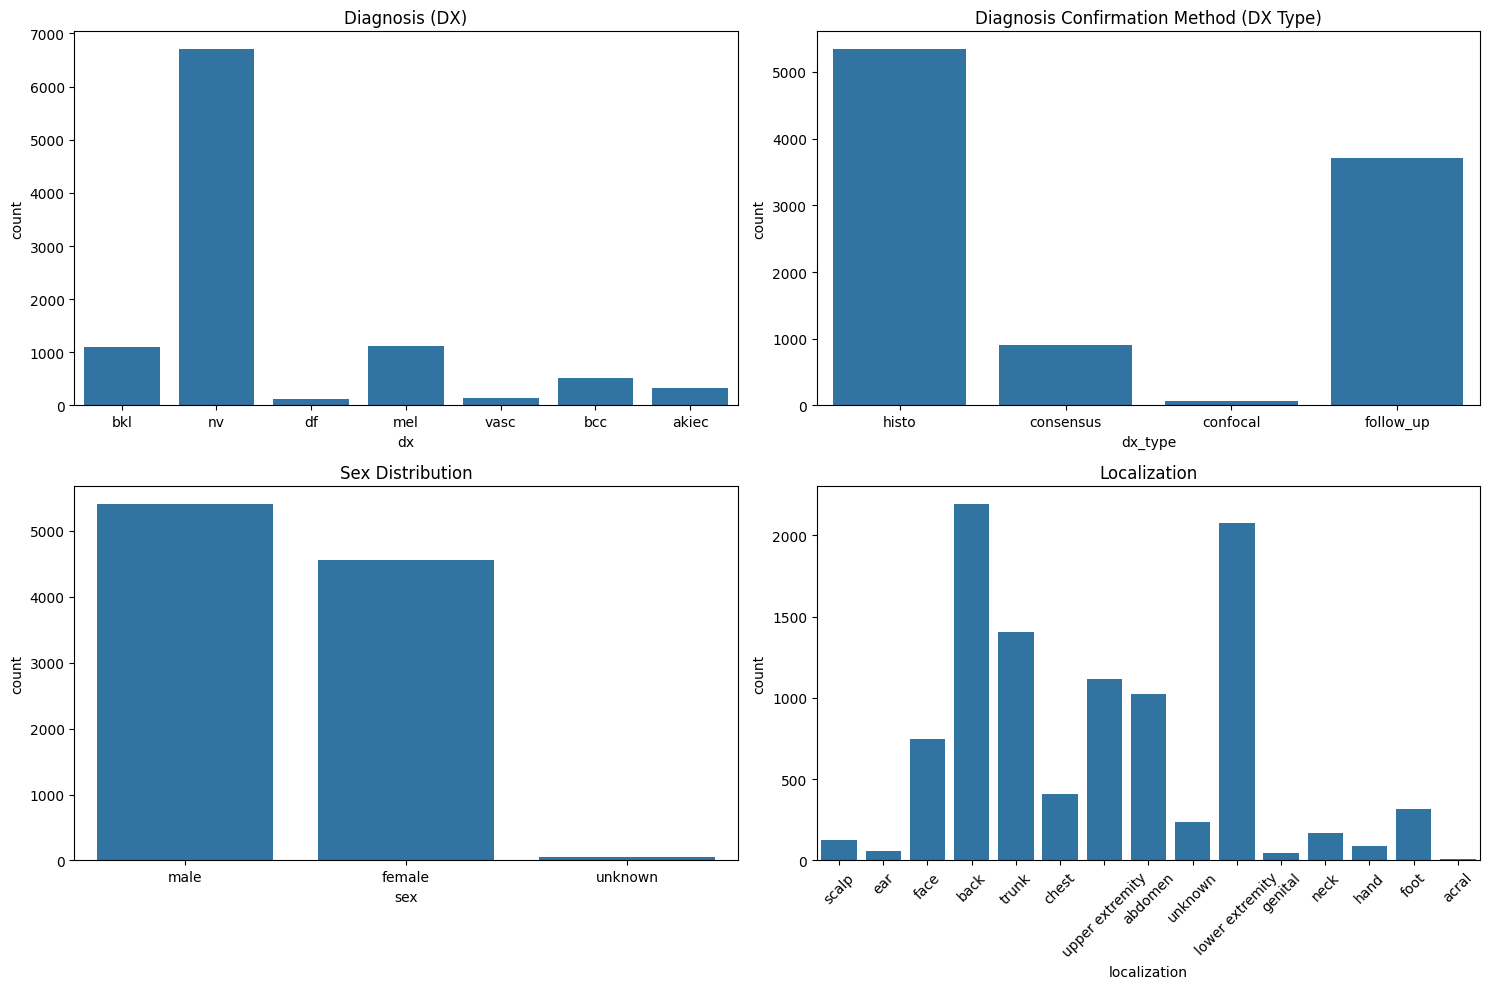

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].set_title('Diagnosis (DX)')
axes[0, 1].set_title('Diagnosis Confirmation Method (DX Type)')
axes[1, 0].set_title('Sex Distribution')
axes[1, 1].set_title('Localization')

sns.countplot(data=df, x='dx', ax=axes[0, 0])
sns.countplot(data=df, x='dx_type', ax=axes[0, 1])
sns.countplot(data=df, x='sex', ax=axes[1, 0])
sns.countplot(data=df, x='localization', ax=axes[1, 1])
axes[1, 1].tick_params(axis='x', rotation=45, labelrotation=45)

plt.tight_layout()
plt.show()

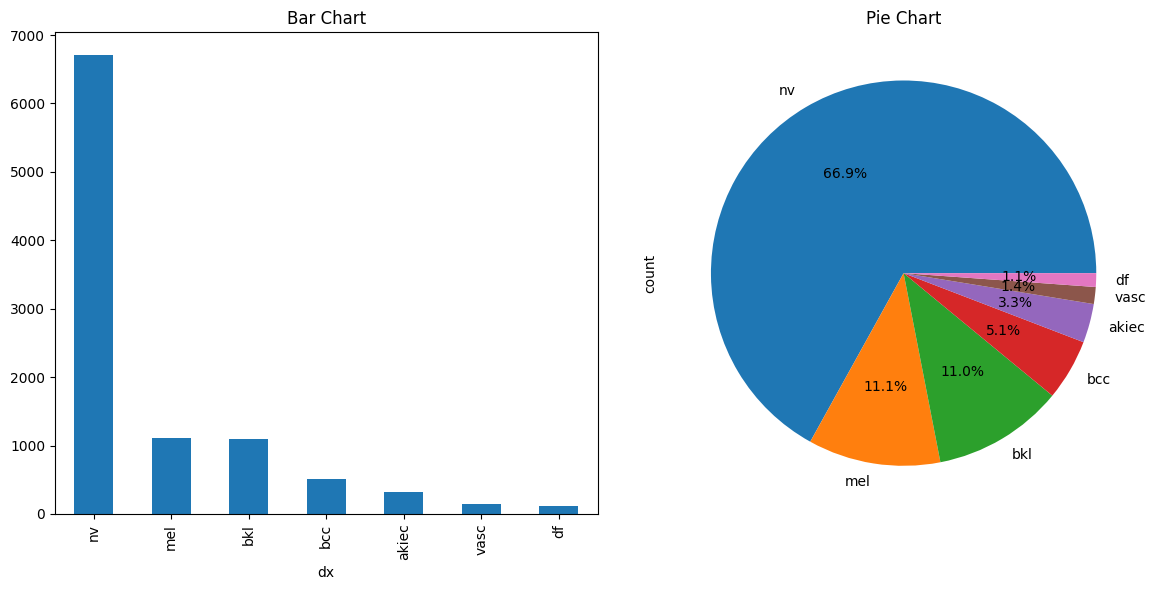

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

df['dx'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Bar Chart')

df['dx'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Pie Chart')

plt.tight_layout()
plt.show()

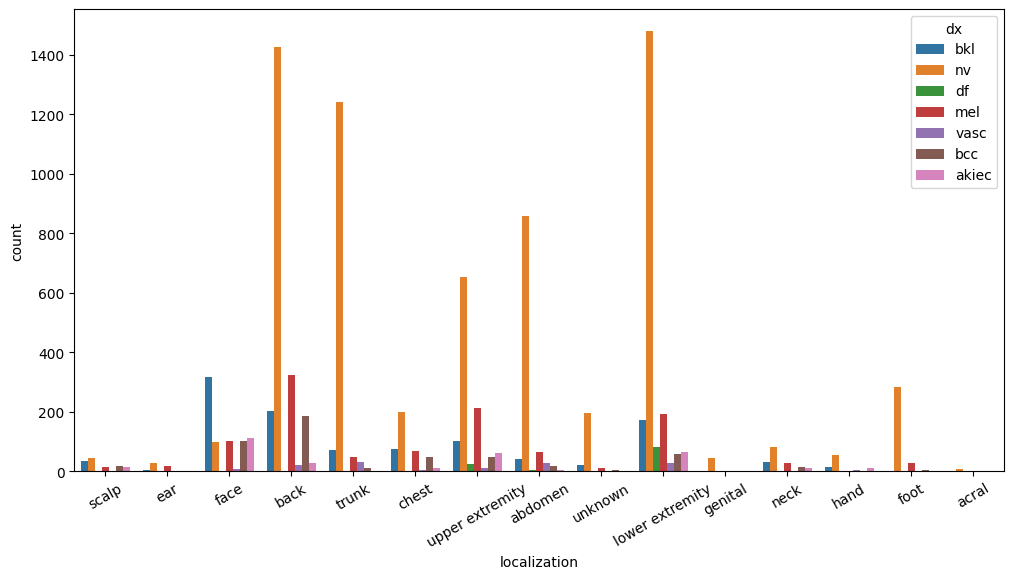

In [ ]:
sns.countplot(data=df, hue='dx', x='localization').tick_params(axis='x', rotation=30, labelrotation=30)

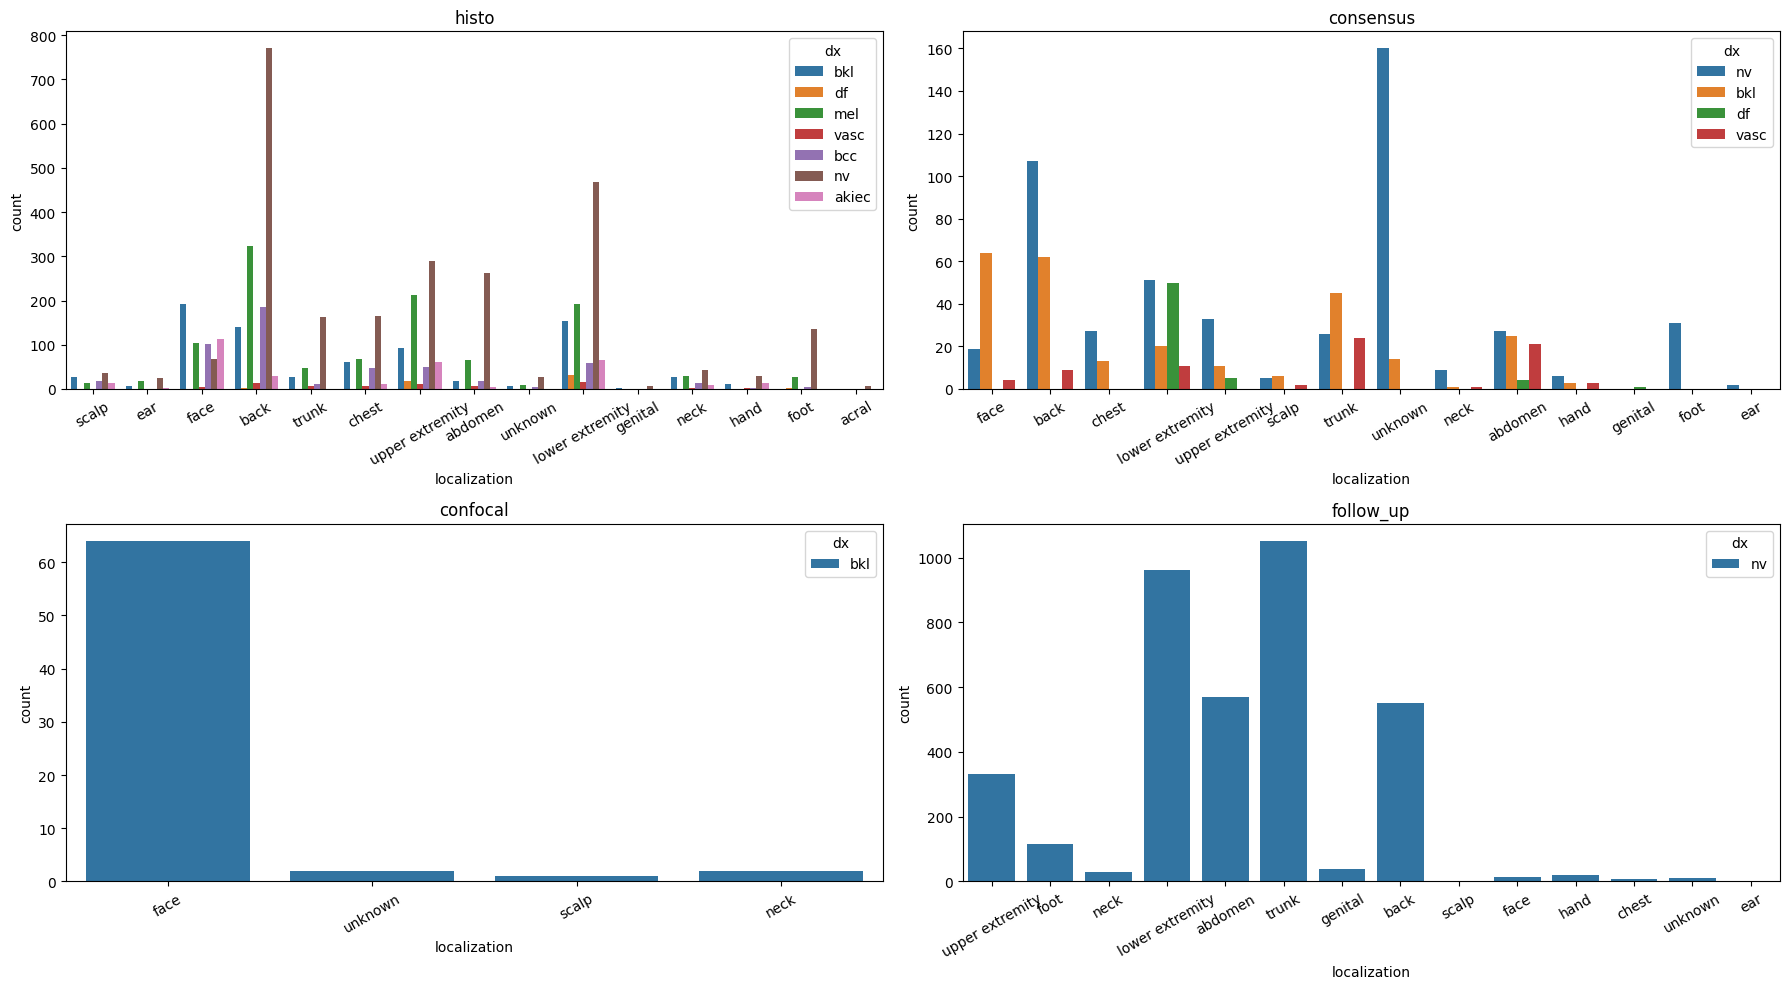

In [98]:
_,ax = plt.subplots(2,2,figsize=(18,10))
ax = ax.flatten()
for idx,dx_type in enumerate(df['dx_type'].unique()):
    dx_type_filterd_df = df[df['dx_type'] == dx_type]
    ax[idx].set_title(dx_type)
    sns.countplot(data=dx_type_filterd_df, hue='dx', x='localization',ax=ax[idx]).tick_params(axis='x', rotation=30, labelrotation=30)
    plt.tight_layout()
    